## 👥 Integrantes

- Leonardo Yeret Ortiz Valle
- José Manuel Aqué González

# 1. Importar librerías generales

In [166]:
import numpy as np  
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

#%matplotlib inline

# 2. Obtención de datos

In [167]:
# Ubicación de los datos en github
#url = 'https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/USArrests.csv'
#df = pd.read_csv(url)

df = pd.read_csv('datos/indice_paz_mex_impacto-economico_2020.csv')

In [168]:
df


,Estados,Homicidio,Delitos_con_violencia,Delitos_con_armas_fuego,Delincuencia_organizada,Carcel_Sin_sentencia,Impacto_economico_de_la_violencia,Impacto_economico_per_capita_de_la_violencia,porcen_pib
0,AGUASCALIENTES,1.368,3.167,1.490,3.425,1.307,51.9,"36,158",14.5
1,BAJA_CALIFORNIA,5.000,3.296,5.000,5.000,2.110,259.6,"71,413",31.5
2,BAJA_CALIFORNIA_SUR,1.554,3.411,1.274,5.000,1.496,28.8,"35,761",13.4
3,CAMPECHE,1.533,1.223,1.345,1.723,4.297,21.6,"21,543",2.2
4,CHIAPAS,1.544,1.444,1.372,1.629,2.874,78.7,"13,742",17.8
5,CHIHUAHUA,5.000,2.641,4.894,3.290,1.785,233.9,"61,538",29.0
6,COAHUILA,1.495,2.274,1.312,3.204,1.766,59.0,"18,344",6.2
7,COLIMA,5.000,3.344,5.000,4.224,1.418,61.2,"77,957",38.4
8,DURANGO,1.649,2.463,1.455,2.904,2.196,38.6,"20,650",11.5
9,GUANAJUATO,5.000,3.313,5.000,2.657,1.280,420.6,"67,536",41.9


In [169]:
#todas las filas de la columna 0 a la 5
df = df.iloc[:,0:6]

In [170]:
df.head()

,Estados,Homicidio,Delitos_con_violencia,Delitos_con_armas_fuego,Delincuencia_organizada,Carcel_Sin_sentencia
0,AGUASCALIENTES,1.368,3.167,1.490,3.425,1.307
1,BAJA_CALIFORNIA,5.000,3.296,5.000,5.000,2.110
2,BAJA_CALIFORNIA_SUR,1.554,3.411,1.274,5.000,1.496
3,CAMPECHE,1.533,1.223,1.345,1.723,4.297
4,CHIAPAS,1.544,1.444,1.372,1.629,2.874


# 3. Análisis Exploratorio

In [171]:
#Principales parámetros estadísticos
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Homicidio,32.0,2.720625,1.287674,1.167,1.63275,2.1860,3.59925,5.000
Delitos_con_violencia,32.0,2.705656,0.847171,1.133,2.27850,2.7295,3.30025,4.783
Delitos_con_armas_fuego,32.0,2.575781,1.260074,1.042,1.49675,2.3575,3.15475,5.000
Delincuencia_organizada,32.0,2.883594,1.102784,1.454,1.82275,2.7020,3.57425,5.000
Carcel_Sin_sentencia,32.0,1.895000,0.862432,1.271,1.41700,1.5270,1.89400,5.000


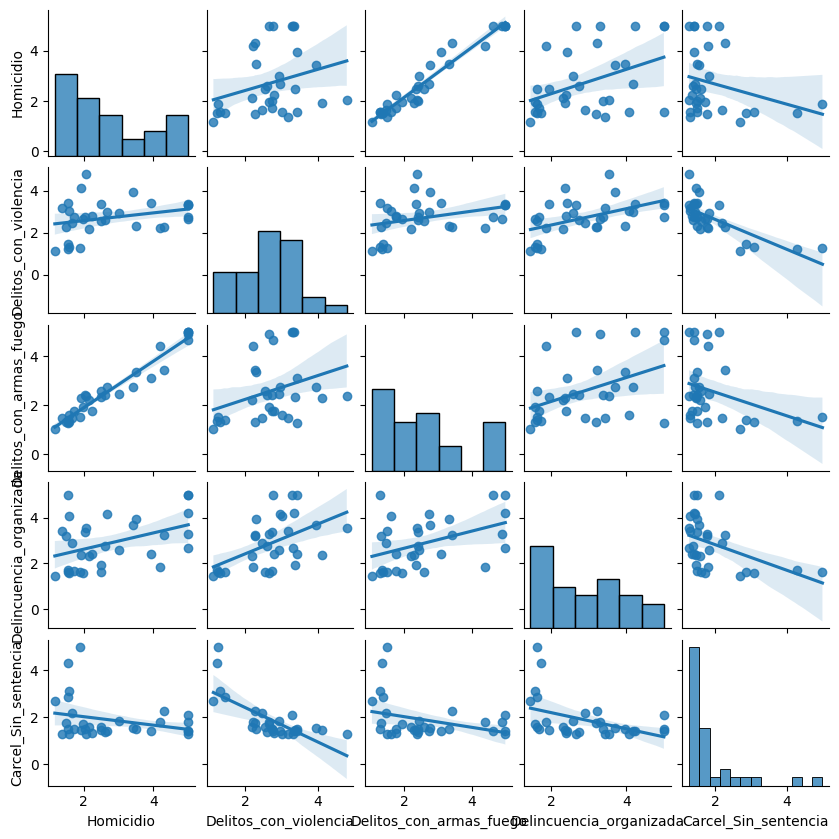

In [172]:
# Correlación lineal de variables
sns.pairplot(df, kind="reg",  height=1.7 , aspect=1)

# 4. Normalización de datos

In [173]:
#Selección de caracteristicas para llevar a cabo el agrupamiento
features = ['Homicidio','Delitos_con_violencia','Delitos_con_armas_fuego','Delincuencia_organizada','Carcel_Sin_sentencia']

In [174]:
#Re-esalamiento de variables
from sklearn import preprocessing
df_standardized = preprocessing.scale(df[features])

In [175]:
df_standardized 

array([[-1.06724887e+00,  5.53283611e-01, -8.75468305e-01,
         4.98800656e-01, -6.92702647e-01],
       [ 1.79847363e+00,  7.07991648e-01,  1.95465401e+00,
         1.94985711e+00,  2.53284131e-01],
       [-9.20491057e-01,  8.45909665e-01, -1.04962968e+00,
         1.94985711e+00, -4.70048225e-01],
       [-9.37060488e-01, -1.77813052e+00, -9.92382190e-01,
        -1.06926162e+00,  2.82971387e+00],
       [-9.28381262e-01, -1.51308807e+00, -9.70612018e-01,
        -1.15586435e+00,  1.15332635e+00],
       [ 1.79847363e+00, -7.75414070e-02,  1.86918593e+00,
         3.74424389e-01, -1.29587230e-01],
       [-9.67043267e-01, -5.17679775e-01, -1.01899018e+00,
         2.95192100e-01, -1.51970479e-01],
       [ 1.79847363e+00,  7.65557429e-01,  1.95465401e+00,
         1.23492390e+00, -5.61937351e-01],
       [-8.45534108e-01, -2.91014512e-01, -9.03688898e-01,
         1.88003941e-02,  3.54597783e-01],
       [ 1.79847363e+00,  7.28379529e-01,  1.95465401e+00,
        -2.08762110e-01

(array([5., 7., 5., 4., 1., 1., 1., 2., 1., 5.]),
 array([-1.225842  , -0.92341043, -0.62097887, -0.31854731, -0.01611574,
         0.28631582,  0.58874738,  0.89117894,  1.19361051,  1.49604207,
         1.79847363]),
 <BarContainer object of 10 artists>)

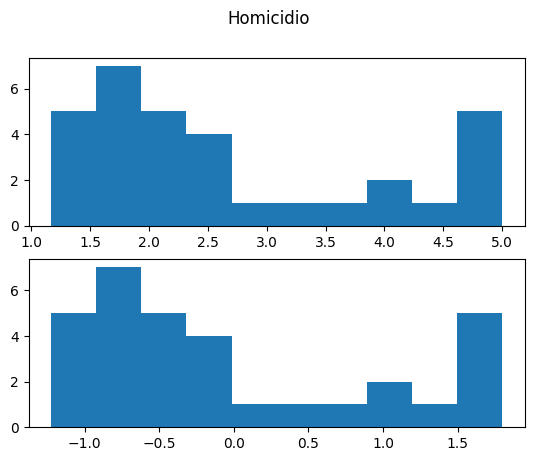

In [176]:
#Comparación antes y despues de la normalización (re-escalamiento)
Delitos_list=df_standardized[:,:1].flatten()
fig, (ax1, ax2) = plt.subplots(2)
fig.suptitle('Homicidio')
ax1.hist(df['Homicidio'])
ax2.hist( Delitos_list)

In [177]:
# Data frame que servirá para la predicción de grupos
df_standardized = pd.DataFrame(df_standardized)

In [178]:
df_standardized.head()

,0,1,2,3,4
0,-1.067249,0.553284,-0.875468,0.498801,-0.692703
1,1.798474,0.707992,1.954654,1.949857,0.253284
2,-0.920491,0.845910,-1.049630,1.949857,-0.470048
3,-0.937060,-1.778131,-0.992382,-1.069262,2.829714
4,-0.928381,-1.513088,-0.970612,-1.155864,1.153326


# 5. Separación de los datos en grupos

In [179]:
# Llamamos al algoritmo y lo ejecutamos  para 1 cluster
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 1, init = 'k-means++', random_state = 42)
kmeans.fit(df_standardized)
# Valor de WCSS
kmeans.inertia_

160.0

# 6. Método del codo

In [180]:
# Se obtienen los diferentes valores de WCSS 
wcss = []
for i in range(1, 13):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(df_standardized)
    wcss.append(kmeans.inertia_)

In [181]:
wcss

[160.0,
 101.76936096533572,
 55.40663546114852,
 48.804776536211385,
 35.559795596637514,
 33.85837556940268,
 30.80747385606199,
 21.655836657204944,
 19.398330524957185,
 15.278455535232512,
 14.331035815739352,
 12.341221259992238]

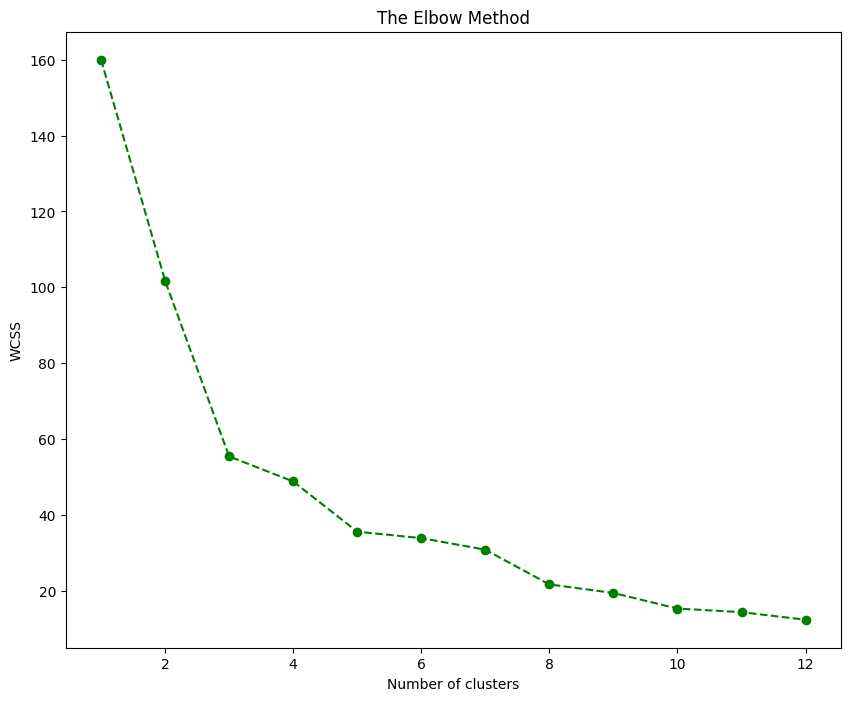

In [182]:
# Grafica de los valores de WCSS 
plt.figure(figsize=(10, 8))
plt.plot(range(1, 13), wcss,"go--")
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# 7. Análisis de resultados

In [183]:
# Predicción de etiquetas
kmeans = KMeans(n_clusters = 8, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(df_standardized)
y_kmeans

array([4, 3, 4, 7, 2, 3, 0, 3, 0, 1, 6, 0, 0, 5, 5, 1, 1, 7, 6, 0, 0, 4,
       5, 6, 0, 6, 0, 0, 2, 0, 2, 3], dtype=int32)

In [184]:
# Cambiamos los valores de los grupos para comenzar en 1 y lo agregamos al dataframe original
df['cluster'] = y_kmeans + 1
df.head()

,Estados,Homicidio,Delitos_con_violencia,Delitos_con_armas_fuego,Delincuencia_organizada,Carcel_Sin_sentencia,cluster
0,AGUASCALIENTES,1.368,3.167,1.490,3.425,1.307,5
1,BAJA_CALIFORNIA,5.000,3.296,5.000,5.000,2.110,4
2,BAJA_CALIFORNIA_SUR,1.554,3.411,1.274,5.000,1.496,5
3,CAMPECHE,1.533,1.223,1.345,1.723,4.297,8
4,CHIAPAS,1.544,1.444,1.372,1.629,2.874,3


<Axes: xlabel='Homicidio', ylabel='Delitos_con_violencia'>

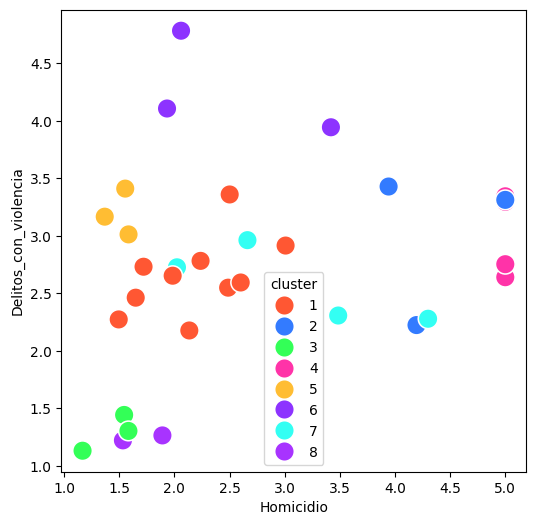

In [185]:
# Observamos la distribución de grupos en un par de variables
plt.figure(figsize=(6,6))
sns.scatterplot(x='Homicidio', y = 'Delitos_con_violencia', hue='cluster',  
                palette=[ "#FF5733",  # rojo
    "#337BFF",
    "#33FF57", 
    "#FF33A8",
    "#FFBD33",  
    "#8D33FF",  
    "#33FFF3",  
    "#A833FF"  ] , data=df, s=200)

<Figure size 500x500 with 0 Axes>

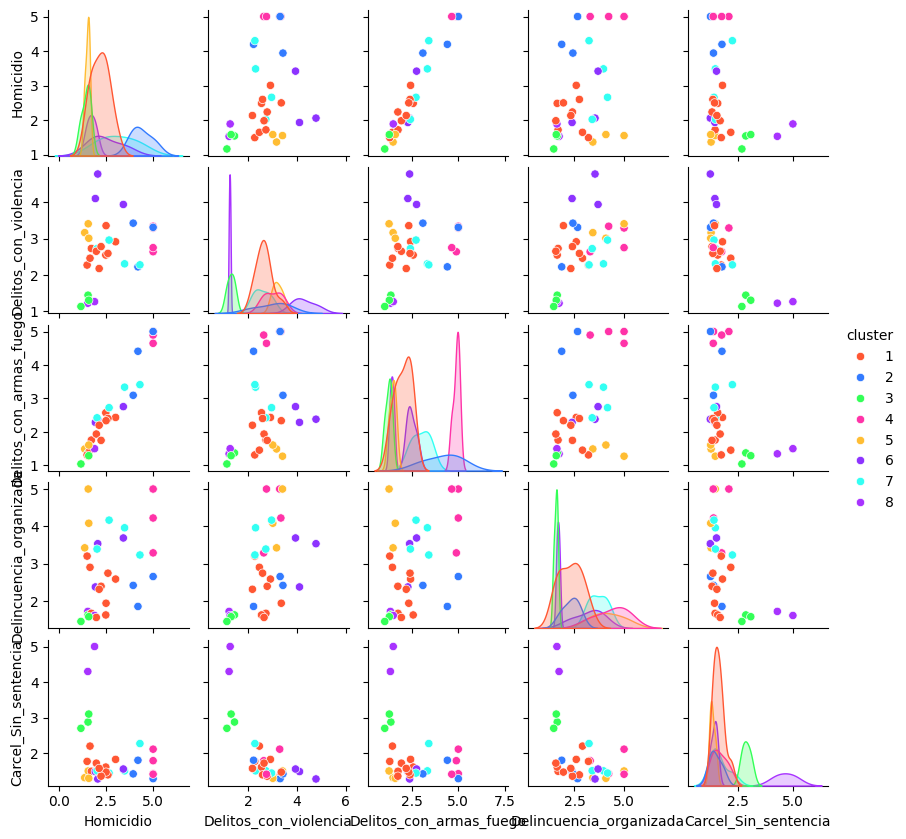

In [186]:
#Comparando a pares las variables
fig = plt.figure(figsize=(5, 5))
sns.pairplot(df, hue="cluster",  palette=[ "#FF5733",  # rojo
    "#337BFF",
    "#33FF57", 
    "#FF33A8",
    "#FFBD33",  
    "#8D33FF",  
    "#33FFF3",  
    "#A833FF"  ],height=1.7 , aspect=1)
plt.show()

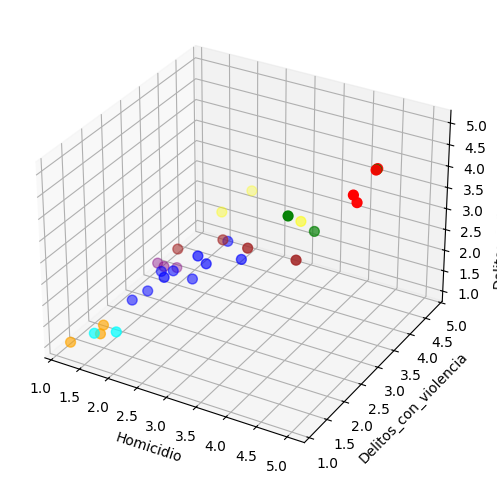

In [187]:
#Comparando los tres tipos de delitos

#%matplotlib notebook
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors

fig = plt.figure(figsize=(8, 6))
#ax = Axes3D(fig)
ax = fig.add_subplot(projection='3d')

x = df['Homicidio']
y = df['Delitos_con_violencia']
z = df['Delitos_con_armas_fuego']
colors = df['cluster']
cmap = matplotlib.colors.ListedColormap(['blue','green','orange','red','purple','yellow','brown','cyan'])
g=ax.scatter(x, y, z, s=50,  c =  colors  , cmap=cmap  )

ax.set_xlabel('Homicidio')
ax.set_ylabel('Delitos_con_violencia')
ax.set_zlabel('Delitos_con_armas_fuego')

legend = ax.legend(*g.legend_elements(), loc="lower center", title="Cluster", borderaxespad=-10, ncol=4)
ax.add_artist(legend)
#ax.view_init(elev=20, azim=35, roll=0)


plt.show()

In [188]:
# Se define un dataframe para mostrar la informacion en un mapa
df_map  = df
df_map.head()

,Estados,Homicidio,Delitos_con_violencia,Delitos_con_armas_fuego,Delincuencia_organizada,Carcel_Sin_sentencia,cluster
0,AGUASCALIENTES,1.368,3.167,1.490,3.425,1.307,5
1,BAJA_CALIFORNIA,5.000,3.296,5.000,5.000,2.110,4
2,BAJA_CALIFORNIA_SUR,1.554,3.411,1.274,5.000,1.496,5
3,CAMPECHE,1.533,1.223,1.345,1.723,4.297,8
4,CHIAPAS,1.544,1.444,1.372,1.629,2.874,3


In [189]:
df_map['Estados'] = df_map['Estados'].str.replace('_', ' ').str.title()
df_map['Estados'] = df_map['Estados'].replace({
    'Ciudad De México': 'México',
    'Estado De México': 'Distrito Federal'
})
df_map['Estados']


0          Aguascalientes
1         Baja California
2     Baja California Sur
3                Campeche
4                 Chiapas
5               Chihuahua
6                Coahuila
7                  Colima
8                 Durango
9              Guanajuato
10               Guerrero
11                Hidalgo
12                Jalisco
13       Distrito Federal
14                 México
15              Michoacán
16                Morelos
17                Nayarit
18             Nuevo León
19                 Oaxaca
20                 Puebla
21              Querétaro
22           Quintana Roo
23        San Luis Potosí
24                Sinaloa
25                 Sonora
26                Tabasco
27             Tamaulipas
28               Tlaxcala
29               Veracruz
30                Yucatán
31              Zacatecas
Name: Estados, dtype: object

In [190]:
# Información geográfica de los Estados Unidos
estados_geo = 'datos/estadosGEO_mx.json'

In [193]:
# Librería Python que permite crear mapas interactivos 
import folium
map = folium.Map(location=[23.6345, -102.5528], tiles='cartodbpositron',zoom_start=5)

In [194]:
folium.Choropleth(geo_data=estados_geo, data=df_map, # geo_path=country_geo, data=plot_data,
             columns=['Estados', 'cluster'],
             key_on='feature.properties.name',
             fill_color='Paired', fill_opacity=0.9, line_opacity=0.9
                 ).add_to(map)
map

## Observaciones

<img src="figuras/analisis_datos.jpg" align="middle" style="width:850px;"/></td>

Grupo 1(azul): La región del Sureste  los asesinatos tienen altos índices de asesinatos.

Grupo 2(verde): Se encuentra en el Centro y tiene valores promedio. 

Grupo 3(anaranjado-rosa): Se encuentra al Norte y se destaca por la tasa mínima de delitos.

Grupo 4(rojo): Los estados del Suroeste  tienen los mas altos índices de asaltos y violaciones.

